# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [3]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

Mỗi dòng trong dữ liệu biểu diễn **một khách hàng của nhà phân phối thực phẩm**.
Mục tiêu là phân nhóm khách hàng dựa trên **hành vi chi tiêu**, do đó chỉ sử dụng 6 biến chi tiêu:
- Fresh
- Milk
- Grocery
- Frozen
- Detergents_Paper
- Delicassen

Các biến này phản ánh mức chi tiêu hằng năm của khách hàng ở từng nhóm sản phẩm và là thông tin trực tiếp phục vụ bài toán segmentation.
Nếu tồn tại các cột như `Channel` hoặc `Region`, chúng chỉ đóng vai trò thông tin mô tả (context), chưa được dùng làm input cho mô hình ở giai đoạn đầu.

Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?

- Không có giá trị thiếu (missing values).
- Không có dòng dữ liệu trùng lặp (duplicate rows).
- Các biến chi tiêu đều có kiểu dữ liệu số nên phù hợp để phân cụm.
- Một số khách hàng có giá trị chi tiêu bằng 0 ở một số nhóm sản phẩm. Đây có thể là trường hợp khách hàng không mua nhóm hàng đó nên không xem là dữ liệu lỗi và
vẫn được giữ lại.
- Phân phối của các biến chi tiêu lệch phải và có nhiều giá trị rất lớn (outlier). Vì các thuật toán clustering dựa trên khoảng cách khá nhạy với outlier, cần cân nhắc bước chuẩn hóa dữ liệu và có thể sử dụng phương pháp scaling phù hợp như RobustScaler hoặc StandardScaler.

Channel/Region (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?

- Channel và Region không nên được dùng làm đầu vào của mô hình clustering ở giai đoạn đầu vì mục tiêu là khám phá các nhóm khách hàng chỉ dựa trên hành vi chi tiêu. Nếu đưa các biến này vào mô hình, kết quả phân cụm có thể bị chi phối bởi thông tin về kênh bán hàng hoặc khu vực thay vì phản ánh sự khác biệt trong hành vi mua sắm.
- Sau khi phân cụm, hai biến này có thể được sử dụng để phân tích xem mỗi cụm tập trung ở kênh bán hàng hoặc khu vực nào, từ đó hỗ trợ diễn giải kết quả và xây dựng chiến lược kinh doanh.

Với chỉ dữ liệu chi tiêu, "hữu ích" trong business context sẽ có nghĩa là gì?

- Các cụm có hành vi chi tiêu khác biệt rõ ràng.
- Mỗi cụm có đặc điểm dễ diễn giải và có thể đặt tên.
- Từ mỗi cụm có thể đề xuất hành động kinh doanh cụ thể, chẳng hạn: xây dựng chương trình khuyến mãi phù hợp, gợi ý bán chéo (cross-selling), ưu tiên chăm sóc khách hàng giá trị cao, thiết kế chiến lược marketing riêng cho từng nhóm.
- Nếu các cụm không khác biệt đáng kể hoặc không thể chuyển thành hành động thực tế thì việc phân cụm sẽ ít mang lại giá trị cho doanh nghiệp.

In [7]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)
display(df.dtypes)
display(df.isnull().sum())
display((X_raw == 0).sum())

,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


Channel             int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

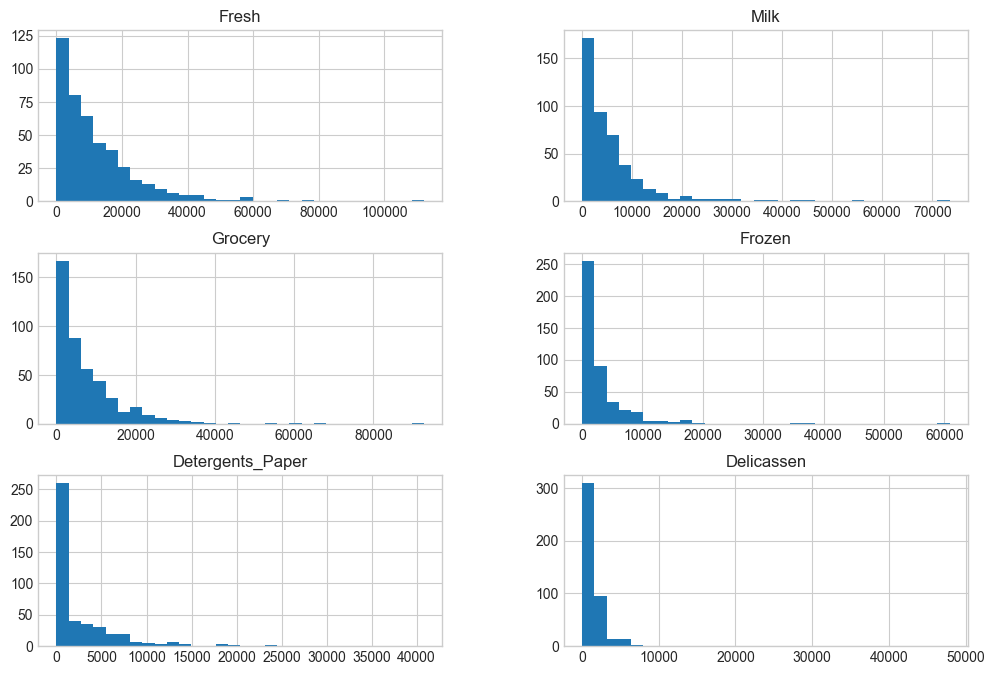

In [ ]:
X_raw.hist(figsize=(12, 8), bins=30)
plt.show()

Hầu hết các biến có phân phối lệch phải (right-skewed). Phần lớn khách hàng có mức chi tiêu thấp trong khi chỉ một số ít có mức chi tiêu rất cao. Điều này có thể ảnh hưởng đến các thuật toán dựa trên khoảng cách như K-Means vì các giá trị lớn sẽ chi phối khoảng cách Euclidean. Do đó cần xem xét chuẩn hóa dữ liệu trước khi phân cụm.

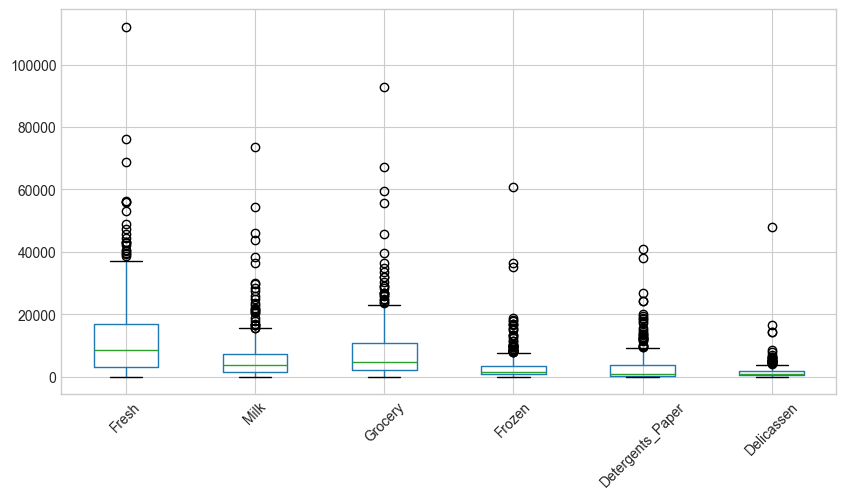

In [10]:
X_raw.boxplot(figsize=(10, 5))
plt.xticks(rotation=45)
plt.show()

Tất cả các biến đều xuất hiện nhiều outlier. Các điểm cực trị có thể kéo tâm cụm của K-Means và làm giảm chất lượng phân cụm. Điều này gợi ý nên thử các phương pháp preprocessing như RobustScaler hoặc biến đổi log để giảm ảnh hưởng của outlier.

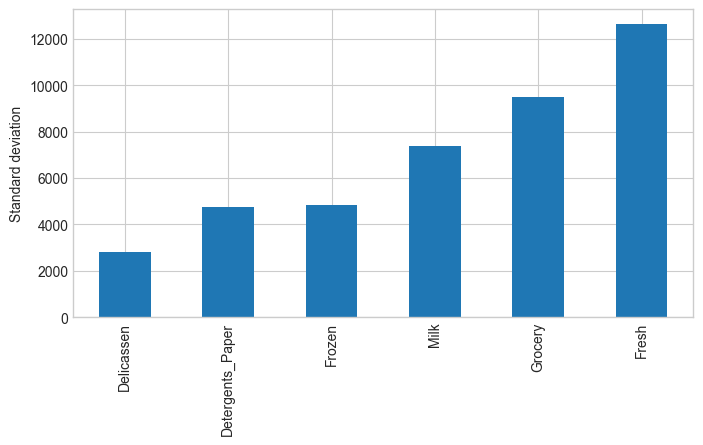

In [11]:
X_raw.std().sort_values().plot.bar(figsize=(8,4))
plt.ylabel("Standard deviation")
plt.show()

Độ biến thiên giữa các feature khác nhau đáng kể. Ví dụ Fresh có độ lệch chuẩn lớn hơn nhiều so với Delicassen. Nếu không chuẩn hóa, các feature có giá trị lớn sẽ chi phối khoảng cách giữa các khách hàng. Vì vậy cần thực hiện feature scaling trước khi clustering.

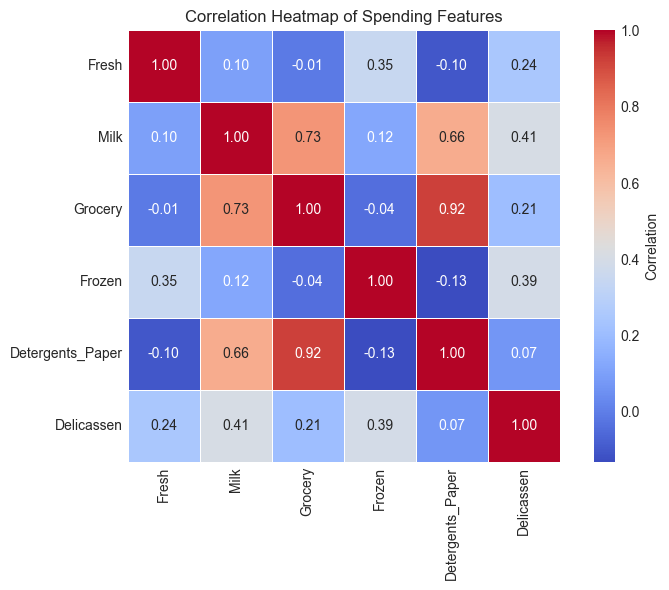

In [12]:
import seaborn as sns
corr = X_raw.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap of Spending Features")
plt.tight_layout()
plt.show()

Heatmap cho thấy Milk, Grocery và Detergents_Paper có hệ số tương quan dương khá cao, nghĩa là khách hàng chi tiêu nhiều cho Grocery thường cũng chi tiêu nhiều cho Milk và Detergents_Paper. Trong khi đó, Fresh, Frozen và Delicassen có mức tương quan yếu hơn với các nhóm còn lại. Điều này gợi ý rằng một số nhóm sản phẩm thường được mua cùng nhau và sẽ hữu ích khi diễn giải đặc điểm của từng cụm sau khi phân cụm.

## Kết luận từ EDA

Các quan sát từ EDA cho thấy:

- Dữ liệu có phân phối lệch phải và nhiều outlier.
- Các feature có thang đo và độ biến thiên rất khác nhau.
- Một số nhóm chi tiêu có tương quan mạnh, đặc biệt Grocery, Milk và Detergents_Paper.
- Vì clustering dựa trên khoảng cách nên cần chuẩn hóa dữ liệu trước khi huấn luyện mô hình.
- Ở bước tiếp theo sẽ thử các phương pháp scaling (StandardScaler, RobustScaler) kết hợp với nhiều thuật toán clustering như K-Means và Clustering để đánh giá chất lượng phân cụm.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [14]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
X_raw_profile = X_raw.copy()
X_log_standard = StandardScaler().fit_transform(np.log1p(X_raw))
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))
X_model = X_log_standard

# Xử lý skew:
- Các biến chi tiêu đều có phân phối lệch phải và chứa nhiều giá trị rất lớn. Do toàn bộ giá trị đều không âm, áp dụng np.log1p() giúp giảm độ lệch của phân phối và giảm ảnh hưởng của các giá trị cực lớn.

# Xử lý khác biệt scale:
- Sau khi biến đổi log, các feature vẫn có thang đo khác nhau. StandardScaler được sử dụng để đưa các feature về cùng thang đo (mean = 0, std = 1), giúp các biến đóng góp tương đối đồng đều khi tính khoảng cách Euclidean.

# Matrix dùng để fit model:
- X_model được sử dụng để huấn luyện các thuật toán clustering vì nó đã xử lý đồng thời vấn đề skew và khác biệt về scale giữa các feature.

# Bảo toàn dữ liệu gốc:
- X_raw được giữ nguyên để tính thống kê và xây dựng profile của từng cụm theo đơn vị chi tiêu ban đầu, giúp kết quả dễ diễn giải trong bối cảnh kinh doanh.

# Trade-off
- Biến đổi log1p() làm giảm ảnh hưởng của các outlier nhưng cũng thu hẹp khoảng cách giữa các khách hàng có mức chi tiêu rất cao. Nếu những khách hàng này tạo thành một phân khúc quan trọng, khả năng tách riêng cụm đó có thể giảm.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [ ]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

kmeans = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=RANDOM_STATE
)
labels_kmeans = kmeans.fit_predict(X_model)
print("Number of clusters:", len(np.unique(labels_kmeans)))
print(pd.Series(labels_kmeans).value_counts().sort_index())

Number of clusters: 3
0    145
1    212
2     83
Name: count, dtype: int64
Number of clusters: 3
0    262
1     53
2    125
Name: count, dtype: int64


## Evidence:

- Tạo được 3 cụm.
- Kích thước cụm không quá mất cân bằng.
- Thuật toán đơn giản, dễ diễn giải.

## Decision:
Giữ lại để đánh giá.

In [17]:
agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)
labels_agg = agg.fit_predict(X_model)
print("Number of clusters:", len(np.unique(labels_agg)))
print(pd.Series(labels_agg).value_counts().sort_index())

Number of clusters: 3
0    262
1     53
2    125
Name: count, dtype: int64


# Evidence:

- Không cần khởi tạo tâm cụm.
- Có thể phát hiện cấu trúc phân cấp.
- Cho số cụm tương đương K-Means.

## Decision:
Giữ lại để so sánh với K-Means.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [ ]:
print("KMeans")
print("Silhouette:", silhouette_score(X_model, labels_kmeans))
print("Davies-Bouldin:", davies_bouldin_score(X_model, labels_kmeans))
print()
print("Agglomerative")
print("Silhouette:", silhouette_score(X_model, labels_agg))
print("Davies-Bouldin:", davies_bouldin_score(X_model, labels_agg))
print()
print("KMeans")
display(pd.Series(labels_kmeans).value_counts().sort_index())
print("Agglomerative")
display(pd.Series(labels_agg).value_counts().sort_index())

KMeans
Silhouette: 0.2582784274194209
Davies-Bouldin: 1.348236381325146

Agglomerative
Silhouette: 0.2546567404941345
Davies-Bouldin: 1.5389948670687703

KMeans


0    145
1    212
2     83
Name: count, dtype: int64

Agglomerative


0    262
1     53
2    125
Name: count, dtype: int64

In [24]:
labels_seed42 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
).fit_predict(X_model)

labels_seed123 = KMeans(
    n_clusters=3,
    random_state=123,
    n_init=20
).fit_predict(X_model)

ari = adjusted_rand_score(
    labels_seed42,
    labels_seed123
)

print("ARI =", ari)

ARI = 0.9835879948832227


Giá trị ARI gần 1 cho thấy việc thay đổi random seed gần như không làm thay đổi kết quả phân cụm. Điều này chứng tỏ mô hình có tính ổn định tốt.

## Model cuối: K-Means

Tham số:
- n_clusters = 3
- n_init = 20
- random_state = 42

Evidence:
- Silhouette cao nhất.
- Davies–Bouldin thấp nhất.
- Cluster size cân bằng.
- Kết quả ổn định khi thay đổi random seed.

Điều còn chưa chắc chắn:

Việc lựa chọn số cụm vẫn phụ thuộc vào các metric nội bộ và khả năng diễn giải. Nếu có thêm thông tin nghiệp vụ hoặc dữ liệu về doanh thu/lợi nhuận thì số cụm tối ưu có thể khác.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


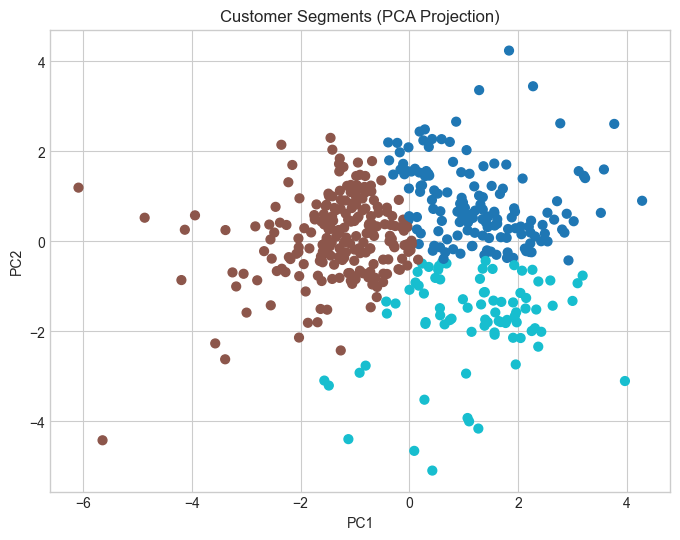

In [ ]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

plt.figure(figsize=(8,6))
plt.scatter(
    coords[:,0],
    coords[:,1],
    c=labels_kmeans,
    cmap="tab10",
    s=40
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA Projection)")
plt.show()

- Visual này cho thấy PCA chiếu dữ liệu từ không gian 6 chiều xuống 2 chiều nhằm giúp quan sát vị trí tương đối giữa các cụm. Nếu các cụm tách biệt trên biểu đồ, điều đó cho thấy mô hình đã tìm được những nhóm khách hàng có xu hướng khác nhau trong không gian đặc trưng.

Không thể kết luận:
- PCA chỉ là phép chiếu tuyến tính từ không gian nhiều chiều xuống hai chiều nên một phần thông tin đã bị mất. Vì vậy, việc các cụm chồng lấn hoặc tách biệt trên biểu đồ không đủ để khẳng định chất lượng thực sự của mô hình. Việc đánh giá vẫn cần dựa trên các chỉ số như Silhouette Score, Davies–Bouldin Score và phân tích đặc điểm của từng cụm.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"12,205.00","7,209.00","9,965.00","2,033.00","3,378.00","2,005.00"
1,"9,635.00","1,598.50","2,151.00","2,151.00",274.50,686.00
2,"1,531.00","6,154.00","10,487.00",398.00,"4,196.00",490.00


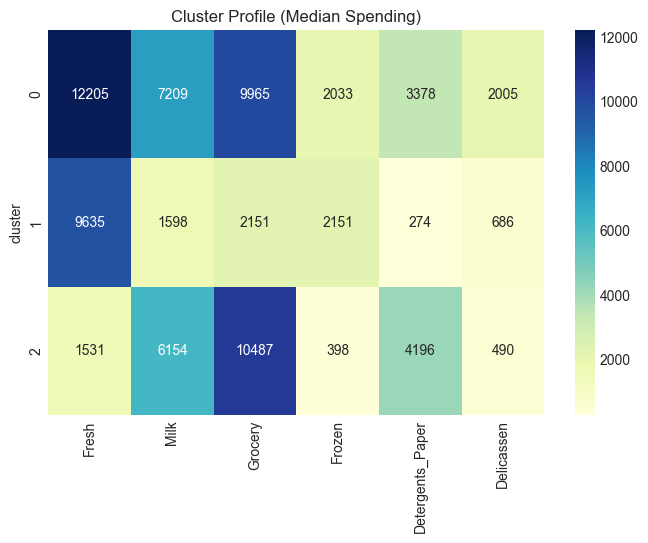

In [34]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
profile = (
    X_raw
    .assign(cluster=labels_kmeans)
    .groupby("cluster")
    .median()
)
display(profile)

plt.figure(figsize=(8,5))
sns.heatmap(
    profile,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Cluster Profile (Median Spending)")
plt.show()

## Cluster A – Fresh-focused customers

- Fresh có median cao nhất.
- Milk và Grocery thấp hơn hai cụm còn lại.
- Frozen cũng khá cao.

## Hypothesis

- Khách hàng trong cụm này có thể quan tâm đến các chương trình khuyến mãi hoặc bán kèm liên quan đến thực phẩm tươi và đông lạnh.

## Cluster B – Grocery & Detergents buyers

- Grocery rất cao.
- Milk cao.
- Detergents_Paper cũng cao.

## Hypothesis

- Nhóm khách hàng này có thể phản hồi tốt với các chương trình bundle giữa Grocery và Detergents_Paper.

## Cluster C – Low spend customers

- Hầu hết feature đều thấp.
- Không có nhóm sản phẩm nổi bật.

## Hypothesis

- Có thể tăng giá trị đơn hàng bằng các chương trình khuyến mãi hoặc ưu đãi cho đơn hàng đầu tiên.

Để xác nhận các giả thuyết trên, cần thêm các thông tin như:

- lợi nhuận của từng nhóm sản phẩm
- tần suất mua hàng
- lịch sử giao dịch theo thời gian
- giá trị đơn hàng
- phản hồi sau các chiến dịch marketing
- tỷ lệ quay lại mua hàng

Nếu không có các dữ liệu này thì các action trên mới chỉ là giả thuyết cần kiểm chứng.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

Kết quả phân tích cho thấy mô hình phân cụm nên được triển khai dưới dạng một thử nghiệm giới hạn (pilot) thay vì áp dụng ngay trên toàn bộ khách hàng. Các cụm thu được có sự khác biệt về hành vi chi tiêu và có thể diễn giải thành các nhóm khách hàng phục vụ mục tiêu marketing, tuy nhiên vẫn cần kiểm chứng bằng dữ liệu thực tế trước khi đưa ra quyết định kinh doanh.

Mô hình cuối sử dụng dữ liệu được tiền xử lý bằng log1p kết hợp với StandardScaler và thuật toán K-Means. Lựa chọn này giúp giảm ảnh hưởng của phân phối lệch, chuẩn hóa thang đo giữa các biến và đạt kết quả tốt hơn trong các chỉ số đánh giá nội bộ (Silhouette Score, Davies–Bouldin Score), đồng thời cho các cụm có kích thước hợp lý và ổn định khi kiểm tra lại.

Hai insight nổi bật là: (1) tồn tại nhóm khách hàng có mức chi tiêu cao tập trung ở một số nhóm sản phẩm, trong khi các nhóm sản phẩm khác thấp hơn đáng kể; và (2) một nhóm khách hàng có mức chi tiêu thấp ở hầu hết các danh mục, cho thấy nhu cầu và giá trị đơn hàng khác biệt rõ ràng.

Một hành động nên thử trước là xây dựng các chương trình khuyến mãi hoặc bán kèm (cross-selling) riêng cho từng cụm khách hàng và đánh giá hiệu quả thông qua doanh thu, giá trị đơn hàng trung bình, tỷ lệ chuyển đổi và tỷ lệ mua lại. Hạn chế lớn nhất của phân tích là dữ liệu chỉ phản ánh tổng chi tiêu theo nhóm sản phẩm, chưa bao gồm lợi nhuận, tần suất mua hàng, lịch sử giao dịch hay phản hồi từ các chiến dịch marketing, vì vậy các hành động đề xuất hiện mới dừng ở mức giả thuyết cần được kiểm chứng.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
